**Purpose**

The purpose of this notebook is to graph growth curves of bacteria growing in the presence of sialidase inhibitor small molecules DANA and Zanamivir.

In [1]:
from elliot_utils import *

In [2]:
analysisPath = Path.cwd().joinpath('analysis_files/sialidase_inhibitor_growth/')
figurePath = Path.cwd().joinpath('figures/sialidase_inhibitor_growth/')

In [3]:
# Returns: The dataDF appended with a new column representing the OD600 for the sample at the given time minus its starting OD600
# dataDF: Dataframe output by the curveData2df function
def calculateDeltaOD(dataDF):
    startingOD = None
    deltaODs = []
    for index, row in dataDF.iterrows():
        if row['Hours'] == 0:
            startingOD = row['OD600']
            deltaODs.append(0)
        else:
            deltaODs.append(row['OD600'] - startingOD)
    dataDF['Delta OD600'] = deltaODs

# Returns: A subset DataFrame of "df" with only data for the specified strains and treatments
# df: A DataFrame generated by the curveData2df function. It will have the headers 'Treatment', 'OD600', 'Hours'
# strains: A list containing strain names
# treatments: A list containing treatment names
# If time limit is set, will only return up to the given time point in hours (inclusive)
# If treatments is set to a list, will only return values for those treatments
def sliceDFBy(df, strains, treatments, timeLimit=1000000000000):
    dataDict = {}
    for key in df.keys():
        dataDict[key] = []
    for index, row in df.iterrows():
        if row['Strain'] in strains and row['Treatment'] in treatments and row['Hours'] <= timeLimit:
            for key in dataDict.keys():
                dataDict[key].append(row[key])
    return pd.DataFrame(dataDict)

In [4]:
data31525 = pd.read_csv(analysisPath.joinpath('3-15-25_Gvaginalis_Htimonensis.csv'))

In [5]:
strainLocs = [
    ['G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1'],
    ['G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1'],
    ['G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1'],
    ['G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1'],
    ['G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1'],
    ['G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'G. vaginalis 315-A', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1', 'H. timonensis 5C-B1'],
    ['Negative', 'Negative', '', '', '', '', '', '', '', '', '', ''],
    ['', '', '', '', '', '', '', '', '', '', '', '']
]
treatmentLocs = [
    ['1000 μM DANA', '1000 μM DANA', '1000 μM DANA', '1000 μM Zanamivir', '1000 μM Zanamivir', '1000 μM Zanamivir', '1000 μM DANA', '1000 μM DANA', '1000 μM DANA', '1000 μM Zanamivir', '1000 μM Zanamivir', '1000 μM Zanamivir'],
    ['200 μM DANA', '200 μM DANA', '200 μM DANA', '200 μM Zanamivir', '200 μM Zanamivir', '200 μM Zanamivir', '200 μM DANA', '200 μM DANA', '200 μM DANA', '200 μM Zanamivir', '200 μM Zanamivir', '200 μM Zanamivir'],
    ['40 μM DANA', '40 μM DANA', '40 μM DANA', '40 μM Zanamivir', '40 μM Zanamivir', '40 μM Zanamivir', '40 μM DANA', '40 μM DANA', '40 μM DANA', '40 μM Zanamivir', '40 μM Zanamivir', '40 μM Zanamivir'],
    ['8 μM DANA', '8 μM DANA', '8 μM DANA', '8 μM Zanamivir', '8 μM Zanamivir', '8 μM Zanamivir', '8 μM DANA', '8 μM DANA', '8 μM DANA', '8 μM Zanamivir', '8 μM Zanamivir', '8 μM Zanamivir'],
    ['1.6 μM DANA', '1.6 μM DANA', '1.6 μM DANA', '1.6 μM Zanamivir', '1.6 μM Zanamivir', '1.6 μM Zanamivir', '1.6 μM DANA', '1.6 μM DANA', '1.6 μM DANA', '1.6 μM Zanamivir', '1.6 μM Zanamivir', '1.6 μM Zanamivir'],
    ['0 μM DANA', '0 μM DANA', '0 μM DANA', '0 μM Zanamivir', '0 μM Zanamivir', '0 μM Zanamivir', '0 μM DANA', '0 μM DANA', '0 μM DANA', '0 μM Zanamivir', '0 μM Zanamivir', '0 μM Zanamivir'],
    ['0 μM DANA', '0 μM Zanamivir', '', '', '', '', '', '', '', '', '', ''],
    ['', '', '', '', '', '', '', '', '', '', '', '']
]
df31525 = curveData2df(data31525, strainLocs, treatmentLocs)
calculateDeltaOD(df31525)

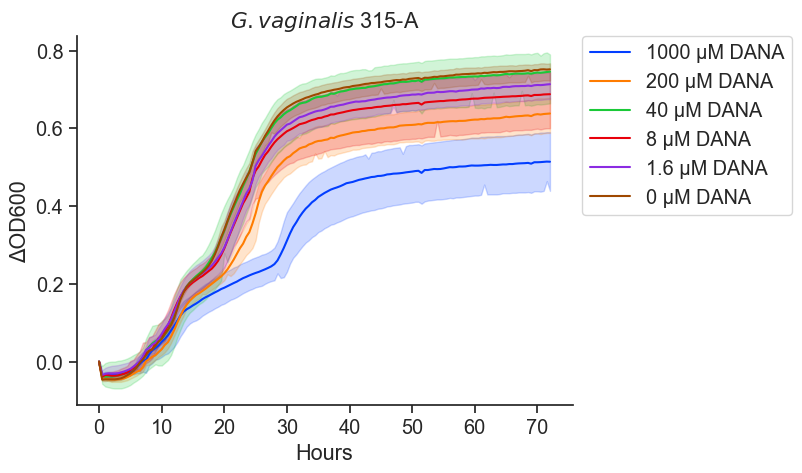

In [7]:
dataToPlot = sliceDFBy(df31525, ['G. vaginalis 315-A'], ['1000 μM DANA', '200 μM DANA', '40 μM DANA', '8 μM DANA', '1.6 μM DANA', '0 μM DANA'])
plot = sns.lineplot(data=dataToPlot, x='Hours', y='Delta OD600', hue='Treatment')
plot.set(title='$\it{G. vaginalis}$ 315-A', ylabel='ΔOD600')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
sns.despine()
saveFig(plot, figurePath.joinpath('gv_DANA.png'))

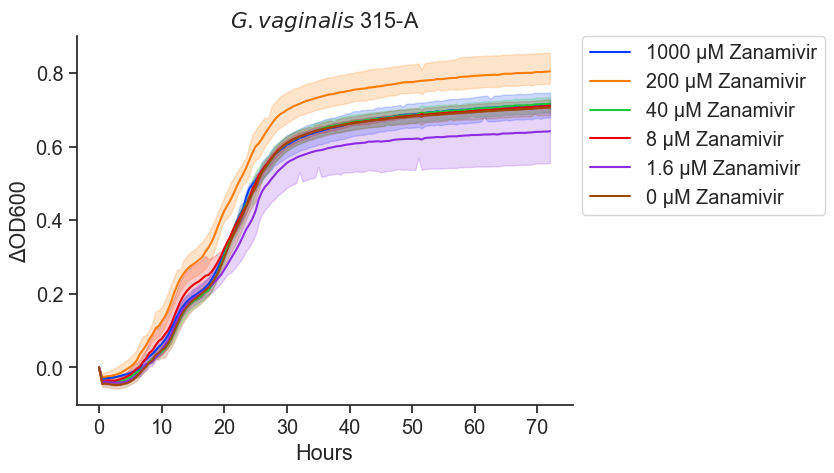

In [8]:
dataToPlot = sliceDFBy(df31525, ['G. vaginalis 315-A'], ['1000 μM Zanamivir', '200 μM Zanamivir', '40 μM Zanamivir', '8 μM Zanamivir', '1.6 μM Zanamivir', '0 μM Zanamivir'])
plot = sns.lineplot(data=dataToPlot, x='Hours', y='Delta OD600', hue='Treatment')
plot.set(title='$\it{G. vaginalis}$ 315-A', ylabel='ΔOD600')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
sns.despine()
saveFig(plot, figurePath.joinpath('gv_zanamivir.png'))

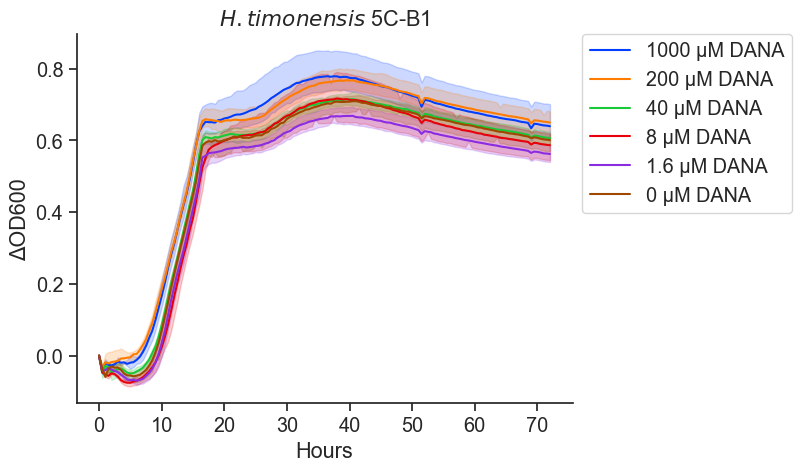

In [9]:
dataToPlot = sliceDFBy(df31525, ['H. timonensis 5C-B1'], ['1000 μM DANA', '200 μM DANA', '40 μM DANA', '8 μM DANA', '1.6 μM DANA', '0 μM DANA'])
plot = sns.lineplot(data=dataToPlot, x='Hours', y='Delta OD600', hue='Treatment')
plot.set(title='$\it{H. timonensis}$ 5C-B1', ylabel='ΔOD600')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
sns.despine()
saveFig(plot, figurePath.joinpath('ht_DANA.png'))

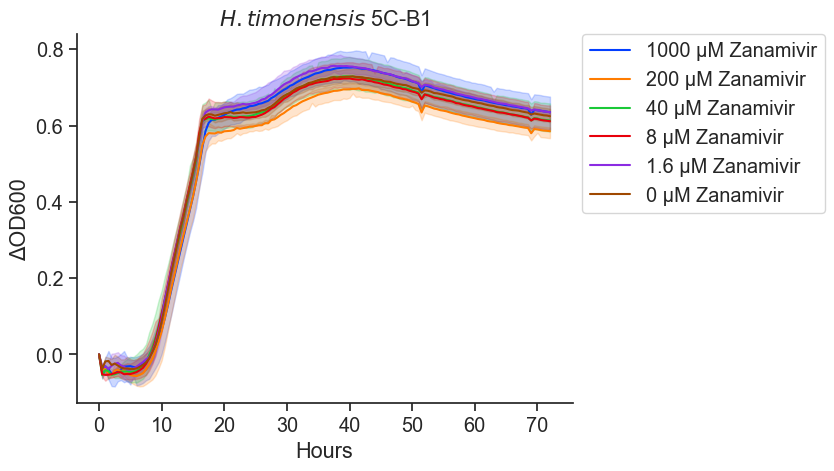

In [10]:
dataToPlot = sliceDFBy(df31525, ['H. timonensis 5C-B1'], ['1000 μM Zanamivir', '200 μM Zanamivir', '40 μM Zanamivir', '8 μM Zanamivir', '1.6 μM Zanamivir', '0 μM Zanamivir'])
plot = sns.lineplot(data=dataToPlot, x='Hours', y='Delta OD600', hue='Treatment')
plot.set(title='$\it{H. timonensis}$ 5C-B1', ylabel='ΔOD600')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
sns.despine()
saveFig(plot, figurePath.joinpath('ht_Zanamivir.png'))